# Build a reduced-order model

In this tutorial we turn a 46-sample full-order sweep of a rectangular
waveguide into a reduced-order model (ROM), sweep 2000 frequencies with it in
a fraction of a second, and measure how accurate it is.

The full-order model (FOM) solves a finite-element system with thousands of
unknowns at every frequency. The ROM is built from the FOM's solutions and has
only a few dozen unknowns, so it can be evaluated at as many frequencies as we
like.

**Prerequisites:** [Your first simulation](first_simulation.ipynb). This
notebook sets up its own project, so it runs on its own.

## 1. Solve the full-order model

The same waveguide and sweep as in the first tutorial, in one cell. We time
the sweep to compare against later.

In [1]:
import time

import numpy as np

from cavsim3d.core.em_project import EMProject

proj = EMProject(name="reduced_order_model", base_dir="./simulations", overwrite=True)
proj.create_primitive("rwg", name="guide", a=0.1, b=0.05, L=0.2, maxh=0.02)

t0 = time.perf_counter()
proj.fds.solve(fmin=0.5, fmax=5.0, nsamples=46)
t_fom = time.perf_counter() - t0
print(f"\nFOM sweep: 46 frequencies in {t_fom:.1f} s")

✅ Creating new project 'reduced_order_model' at simulations\reduced_order_model



Structure Topology
  Type: Single structure
  Domains (1): ['vacuum']
  Ports (2): ['port1', 'port2']
  Mesh elements: 642



Assembling Matrices...


Solving port eigenmodes...


Calculating Port Eigenmodes...


	port1 mode 0: TE_10, kc=31.4159, sigma=+1
	port2 mode 0: TE_10, kc=31.4159, sigma=+1
Port eigenmodes complete: 2 total modes



FDS Solve: 0.5000 - 5.0000 GHz, 46 samples


Global Coupled Solve


  
Coupled solve complete: 2 external ports in 40.80s (total iteration steps: 8662)



FOM sweep: 46 frequencies in 41.2 s


## 2. Reduce the model

### 2.1 Call `reduce()`

`proj.fds.fom` is the full-order model. `reduce()` builds a ROM from the field
solutions (the *snapshots*) the sweep stored. `tol` sets how much of the
snapshot information the ROM must keep: smaller is more accurate.

In [2]:
fom = proj.fds.fom
rom = fom.reduce(tol=1e-6)

Model Order Reduction


Reduction complete: 14130 -> 36 DOFs (99.7% compression)


The line `Reduction complete: ... -> ... DOFs` compares the number of unknowns
(degrees of freedom, DOFs) before and after: over ten thousand become a few
dozen. The ROM was saved to `fds/fom/rom/` in the project folder.

In [3]:
print("reduced size per domain:", rom.reduced_dimensions)

reduced size per domain: {'global': 36}


The single domain of this model is called `global`.

### 2.2 Look at the singular values

The reduction keeps the directions in which the snapshots vary most. Their
importance is measured by singular values; the ROM keeps every direction whose
singular value, relative to the largest, is above `tol`.

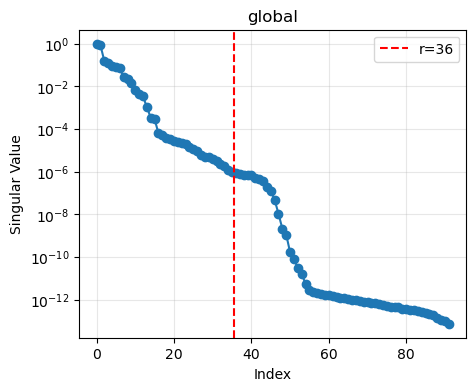

In [4]:
fig, ax = rom.plot_singular_values()

The curve drops by many orders of magnitude; the red dashed line marks the
values kept for `tol=1e-6`. Everything to the right of it carries almost no
information, which is why so few unknowns are enough.

## 3. Sweep with the ROM

### 3.1 Solve at 2000 frequencies

In [5]:
t0 = time.perf_counter()
res_rom = rom.solve(fmin=0.5, fmax=5.0, nsamples=2000)
t_rom = time.perf_counter() - t0

print(f"\nROM sweep: 2000 frequencies in {t_rom:.2f} s "
      f"(FOM: 46 frequencies in {t_fom:.1f} s)")


ROM Solve: 0.5 - 5.0 GHz, 2000 samples


  Solve loop: 0.035s (2000 freq points)



ROM sweep: 2000 frequencies in 0.46 s (FOM: 46 frequencies in 41.2 s)


### 3.2 Read the results

`rom.solve()` returns a dictionary with the same keys as the FOM's:
`'frequencies'` in Hz, and `'S'` and `'Z'` with one matrix per frequency.

In [6]:
print(res_rom["frequencies"].shape, res_rom["S"].shape, res_rom["Z"].shape)

(2000,) (2000, 2, 2) (2000, 2, 2)


## 4. Check the accuracy

### 4.1 Compare the S-parameters

A 2 × 2 grid as in the first tutorial: magnitude in dB on top, phase below,
$S_{11}$ left, $S_{21}$ right. Each panel shows the exact solution as a line,
the 46 FOM samples as circles and the ROM as a dashed line.

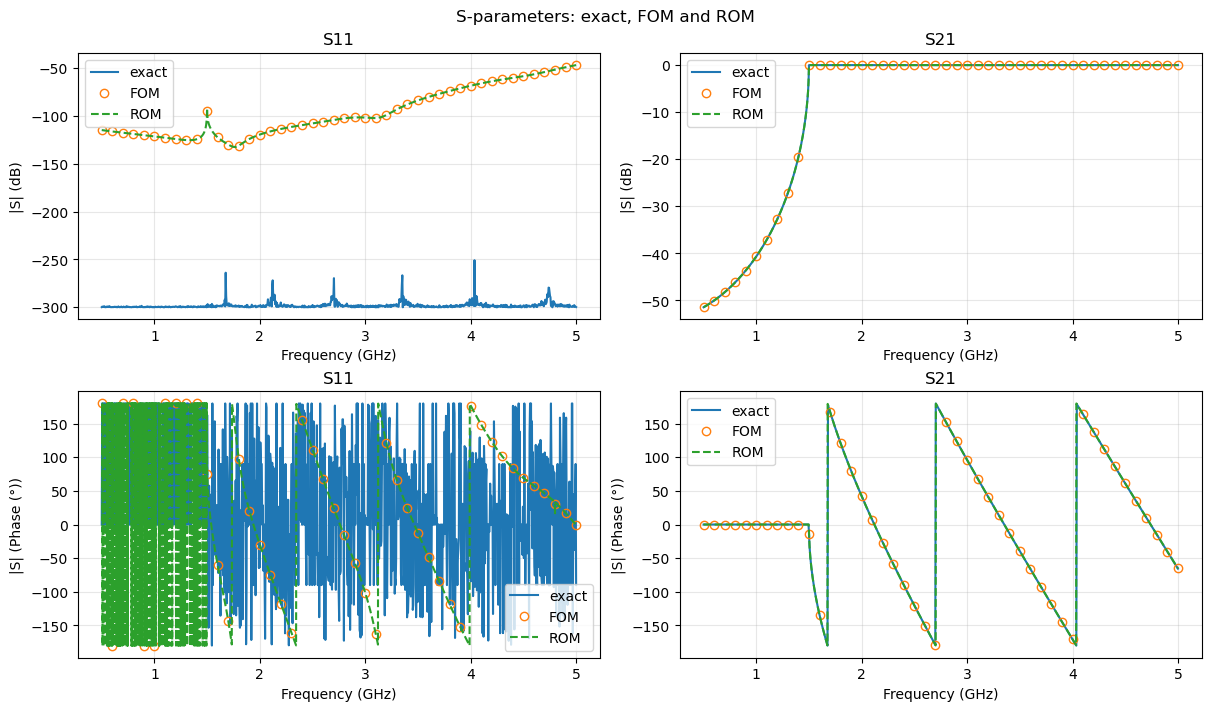

In [7]:
import matplotlib.pyplot as plt

from cavsim3d.analytical import RWGAnalytical

ana = RWGAnalytical(a=0.1, b=0.05, L=0.2, freq_range=(0.5, 5.0))

fig, axs = plt.subplot_mosaic([["11 db", "21 db"], ["11 phase", "21 phase"]],
                              figsize=(12, 7), layout="constrained")
for ij in ("11", "21"):
    label = f"{ij[1]}(1){ij[0]}(1)"
    for kind in ("db", "phase"):
        ax = axs[f"{ij} {kind}"]
        ana.plot_s([label], plot_type=kind, ax=ax, label="exact")
        fom.plot_s([label], plot_type=kind, ax=ax, label="FOM",
                   lw=0, marker="o", mfc="none")
        rom.plot_s([label], plot_type=kind, ax=ax, label="ROM", ls="--",
                   title=f"S{ij}")
fig.suptitle("S-parameters: exact, FOM and ROM")
plt.show()

In the $S_{21}$ panels the dashed ROM curves lie on the exact curves
everywhere, including between the FOM samples: the ROM interpolates, it does
not just repeat the samples. The $S_{11}$ panels show numerical noise, as in
the first tutorial (the exact $S_{11}$ is zero).

### 4.2 Compare the Z-parameters

The impedance has sharp resonance peaks. This is where a fine sweep pays off.

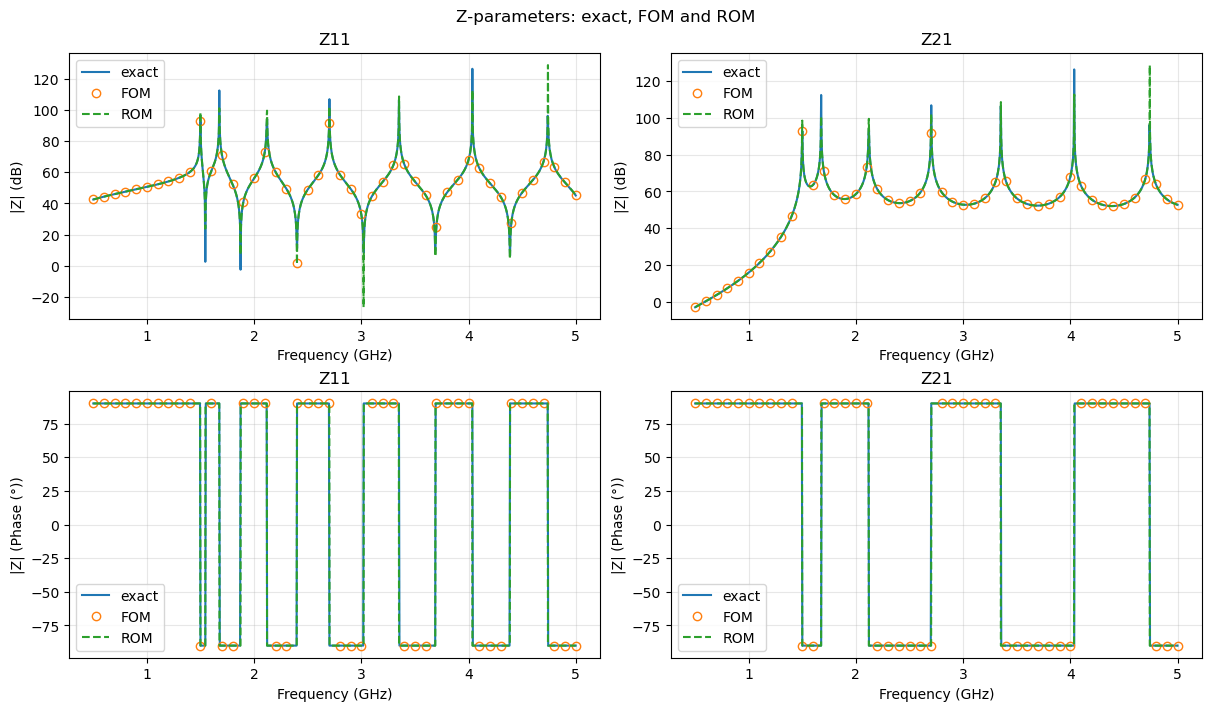

In [8]:
fig, axs = plt.subplot_mosaic([["11 db", "21 db"], ["11 phase", "21 phase"]],
                              figsize=(12, 7), layout="constrained")
for ij in ("11", "21"):
    label = f"{ij[1]}(1){ij[0]}(1)"
    for kind in ("db", "phase"):
        ax = axs[f"{ij} {kind}"]
        ana.plot_z([label], plot_type=kind, ax=ax, label="exact")
        fom.plot_z([label], plot_type=kind, ax=ax, label="FOM",
                   lw=0, marker="o", mfc="none")
        rom.plot_z([label], plot_type=kind, ax=ax, label="ROM", ls="--",
                   title=f"Z{ij}")
fig.suptitle("Z-parameters: exact, FOM and ROM")
plt.show()

The FOM circles straddle the peaks; the 2000-point ROM curve resolves each
peak and its 180° phase jump, and follows the exact solution through them.

### 4.3 Measure the error at every frequency

In [9]:
f_rom = res_rom["frequencies"]
S21_exact = ana.s_parameters(f_rom / 1e9)["S21"]
err_rom = np.abs(res_rom["S"][:, 1, 0] - S21_exact)
print(f"median ROM error: {np.median(err_rom):.1e}, largest: {err_rom.max():.1e}")

median ROM error: 6.7e-05, largest: 3.9e-03


These are the same sizes as the FOM's own errors in the first tutorial. The
ROM adds no error of its own: what remains is the error of the mesh.

### 4.4 See what the tolerance does

Build a second ROM with a much looser tolerance and sweep the same 2000
frequencies. The first result stays in `err_rom` for comparison.

In [10]:
rom_loose = fom.reduce(tol=1e-1)
res_loose = rom_loose.solve(fmin=0.5, fmax=5.0, nsamples=2000)
err_loose = np.abs(res_loose["S"][:, 1, 0] - S21_exact)

print("\nreduced size:", rom_loose.reduced_dimensions)
print(f"median error with tol=1e-1: {np.median(err_loose):.1e}")

Model Order Reduction


Reduction complete: 14130 -> 4 DOFs (100.0% compression)



ROM Solve: 0.5 - 5.0 GHz, 2000 samples


  Solve loop: 0.027s (2000 freq points)



reduced size: {'global': 4}
median error with tol=1e-1: 5.5e-01


With only a few unknowns left the ROM is useless: its error is as large as
$S_{21}$ itself. Plotting both errors against frequency shows the difference:

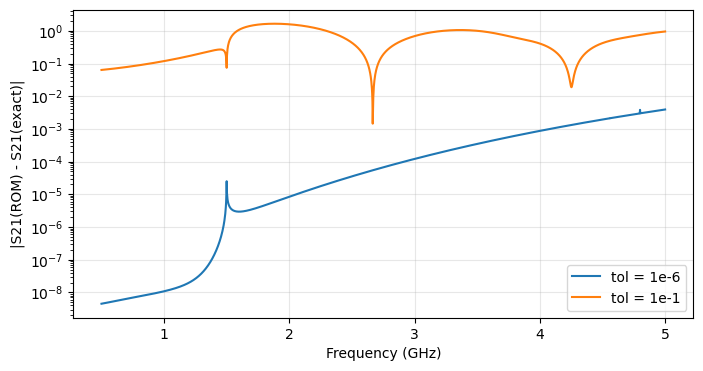

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(f_rom / 1e9, err_rom, label="tol = 1e-6")
ax.semilogy(f_rom / 1e9, err_loose, label="tol = 1e-1")
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("|S21(ROM) - S21(exact)|")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

### 4.5 Keep the accurate ROM

Each call to `reduce()` replaces the project's ROM, so the loose one is now the
one stored in `fds/fom/rom/`. Reduce once more with the tight tolerance:

In [12]:
rom = fom.reduce(tol=1e-6)
print(rom.reduced_dimensions, "| stored as proj.fds.fom.rom:", rom is proj.fds.fom.rom)

Model Order Reduction


Reduction complete: 14130 -> 36 DOFs (99.7% compression)


{'global': 36} | stored as proj.fds.fom.rom: True


## 5. Compare the cost

Every stage recorded its wall time. `timing_summary()` prints them side by
side.

In [13]:
proj.timing_summary();

TIMING SUMMARY - reduced_order_model
Category  Stage          Time [s]  Samples  s/sample 
-----------------------------------------------------
FOM       coupled solve  40.803    46       0.887    
ROM       reduction      0.172     -        -        
ROM       ROM solve      0.453     2000     0.0002263
ROM       reduction      0.119     -        -        
ROM       ROM solve      0.478     2000     0.0002391
ROM       reduction      0.127     -        -        
-----------------------------------------------------
FOM total: 40.803 s
ROM total: 1.349 s
Reduction: 14,130 -> 36 DOFs (99.7% compression)
Speed-up (ROM vs FOM, per sample): 3,709x


Read the `s/sample` column: a ROM frequency point costs a tiny fraction of a
full-order one, and the last line gives the speed-up. For a waveguide this
small the FOM is fast anyway; for a cavity with hundreds of thousands of
unknowns, the same ratio turns hours into seconds.

## What we did

We reduced a 46-sample full-order sweep to a ROM with a few dozen unknowns,
swept 2000 frequencies with it, checked its S- and Z-parameters against the
exact solution, and saw that a too-loose tolerance ruins it.

**Next:** [Find resonances and look at fields](resonances_and_fields.ipynb).

**Background:** [How model order reduction works](../../explanation/model_reduction.md)
explains snapshots, the tolerance, and why a ROM should only be used inside
the band it was trained on.